Creating files...
Loading & preparing data...
Final dataset: (10, 26)


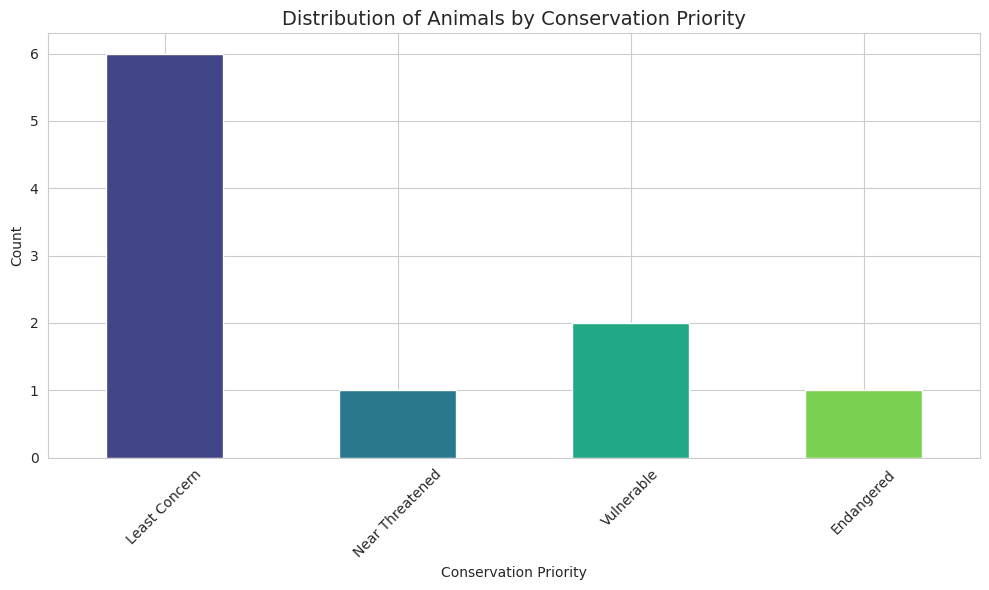

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['class_type']"

In [2]:
# --------------------------------------------------------------
#  TASK 2 – EXPLORATORY DATA ANALYSIS (EDA)
# --------------------------------------------------------------

import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Any
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --------------------------------------------------------------
# 1. CREATE FILES
# --------------------------------------------------------------
def _create_files():
    zoo = """animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
buffalo,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
calf,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
carp,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,4
catfish,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
cavy,1,0,0,1,0,0,0,1,1,1,0,0,4,0,1,0,1
cheetah,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
chicken,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0,2
chub,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
clam,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,7
crab,0,0,1,0,0,1,1,0,0,0,0,0,4,0,0,0,7
crayfish,0,0,1,0,0,1,1,0,0,0,0,0,6,0,0,0,7
crow,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,0,2
deer,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
dogfish,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,1,4
dolphin,0,0,0,1,0,1,1,1,1,1,0,1,0,1,0,1,1
dove,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0,2
duck,0,1,1,0,1,1,0,0,1,1,0,0,2,1,0,0,2
elephant,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
flamingo,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,1,2
flea,0,0,1,0,0,0,0,0,0,1,0,0,6,0,0,0,6
frog,0,0,1,0,0,1,1,1,1,1,0,0,4,0,0,0,5
frog,0,0,1,0,0,1,1,1,1,1,1,0,4,0,0,0,5
fruitbat,1,0,0,1,1,0,0,1,1,1,0,0,2,1,0,0,1
giraffe,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
girl,1,0,0,1,0,0,1,1,1,1,0,0,2,0,1,1,1
gnat,0,0,1,0,1,0,0,0,0,1,0,0,6,0,0,0,6
goat,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
gorilla,1,0,0,1,0,0,0,1,1,1,0,0,2,0,0,1,1
gull,0,1,1,0,1,1,1,0,1,1,0,0,2,1,0,0,2
haddock,0,0,1,0,0,1,0,1,1,0,0,1,0,1,0,0,4
hamster,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,0,1
hare,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,0,1
hawk,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,0,2
herring,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
honeybee,1,0,1,0,1,0,0,0,0,1,1,0,6,0,1,0,6
housefly,1,0,1,0,1,0,0,0,0,1,0,0,6,0,0,0,6
kiwi,0,1,1,0,0,0,1,0,1,1,0,0,2,1,0,0,2
ladybird,0,0,1,0,1,0,1,0,0,1,0,0,6,0,0,0,6
lark,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2
leopard,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
lion,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
lobster,0,0,1,0,0,1,1,0,0,0,0,0,6,0,0,0,7
lynx,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
mink,1,0,0,1,0,1,1,1,1,1,0,0,4,1,0,1,1
mole,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,0,1
mongoose,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
moth,1,0,1,0,1,0,0,0,0,1,0,0,6,0,0,0,6
newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5
octopus,0,0,1,0,0,1,1,0,0,0,0,0,8,0,0,1,7
opossum,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,0,1
oryx,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
ostrich,0,1,1,0,0,0,0,0,1,1,0,0,2,1,0,1,2
parakeet,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0,2
penguin,0,1,1,0,0,1,1,0,1,1,0,0,2,1,0,1,2
pheasant,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2
pike,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,1,4
piranha,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
pitviper,0,0,1,0,0,0,1,1,1,1,1,0,0,1,0,0,3
platypus,1,0,1,1,0,1,1,0,1,1,0,0,4,1,0,1,1
polecat,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
pony,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
porpoise,0,0,0,1,0,1,1,1,1,1,0,1,0,1,0,1,1
puma,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
pussycat,1,0,0,1,0,0,1,1,1,1,0,0,4,1,1,1,1
raccoon,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
reindeer,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
rhea,0,1,1,0,0,0,1,0,1,1,0,0,2,1,0,1,2
scorpion,0,0,0,0,0,0,1,0,0,1,1,0,8,1,0,0,7
seahorse,0,0,1,0,0,1,0,1,1,0,0,1,0,1,0,0,4
seal,1,0,0,1,0,1,1,1,1,1,0,1,0,0,0,1,1
sealion,1,0,0,1,0,1,1,1,1,1,0,1,2,1,0,1,1
seasnake,0,0,0,0,0,1,1,1,1,0,1,0,0,1,0,0,3
seawasp,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,7
skimmer,0,1,1,0,1,1,1,0,1,1,0,0,2,1,0,0,2
skua,0,1,1,0,1,1,1,0,1,1,0,0,2,1,0,0,2
slowworm,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,3
slug,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7
sole,0,0,1,0,0,1,0,1,1,0,0,1,0,1,0,0,4
sparrow,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2
squirrel,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,0,1
starfish,0,0,1,0,0,1,1,0,0,0,0,0,5,0,0,0,7
stingray,0,0,1,0,0,1,1,1,1,0,1,1,0,1,0,1,4
swan,0,1,1,0,1,1,0,0,1,1,0,0,2,1,0,1,2
termite,0,0,1,0,0,0,0,0,0,1,0,0,6,0,0,0,6
toad,0,0,1,0,0,1,0,1,1,1,0,0,4,0,0,0,5
tortoise,0,0,1,0,0,0,0,0,1,1,0,0,4,1,0,1,3
tuatara,0,0,1,0,0,0,1,1,1,1,0,0,4,1,0,0,3
tuna,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,1,4
vampire,1,0,0,1,1,0,0,1,1,1,0,0,2,1,0,0,1
vole,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,0,1
vulture,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,1,2
wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7
wren,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2"""
    Path("/content/zoo.csv").write_text(zoo.strip() + "\n")

    cls = """Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf, cavy, cheetah, deer, dolphin, elephant, fruitbat, giraffe, girl, goat, gorilla, hamster, hare, leopard, lion, lynx, mink, mole, mongoose, opossum, oryx, platypus, polecat, pony, porpoise, puma, pussycat, raccoon, reindeer, seal, sealion, squirrel, vampire, vole, wallaby, wolf"
2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, hawk, kiwi, lark, ostrich, parakeet, penguin, pheasant, rhea, skimmer, skua, sparrow, swan, vulture, wren"
3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, herring, pike, piranha, seahorse, sole, stingray, tuna"
5,4,Amphibian,"frog, frog, newt, toad"
6,8,Bug,"flea, gnat, honeybee, housefly, ladybird, moth, termite, wasp"
7,10,Invertebrate,"clam, crab, crayfish, lobster, octopus, scorpion, seawasp, slug, starfish, worm"
"""
    Path("/content/class.csv").write_text(cls.strip() + "\n")

    aux = """[
  {"animal_name":"aardvark","habitat":"savanna","diet":"insectivore","conservation_status":"least concern"},
  {"animal_name":"antelope","habitat":"grasslands","diet":"herbivore","conservation":"near threatened"},
  {"animal_name":"bass","habitat":"freshwater","diet":"carnivore","conservation_status":"least"},
  {"animal_name":"bear","habitats":"forest","diet":"omnivore","conservation_status":"vulnerable"},
  {"animal_name":"boar","habitat":"forest","diet":"omnivor","status":"least concern"},
  {"animal_name":"buffalo","habitat":"grasslands","diet_type":"herbivore","conservation":"endangered"},
  {"animal_name":"calf","habitat":"domestic","diet":"herbivore"},
  {"animal_name":"carp","habitat":"fresh water","diet":"omnivore","conservation_status":"least concern"},
  {"animal_name":"catfish","habitat":"FreshWater","diet":"carnivore"},
  {"animal_name":"clam","habitat":"marine","diet":"filter_feeder","conservation_status":"least concern"},
  {"animal_name":"crab","habitat":"marine/coastal","diet":"omnivore","conservation":"least concern"},
  {"animal_name":"deer","habitat":"Forest","diet":"Herbivore","conservation_status":"vulnerable"}
]"""
    Path("/content/auxiliary_metadata.json").write_text(aux.strip() + "\n")


# --------------------------------------------------------------
# 2. LOAD & INTEGRATE (with Task E + F)
# --------------------------------------------------------------
def _load_aux_json(p: Path) -> List[Dict[str, Any]]:
    out = []
    with p.open(encoding="utf-8") as f:
        try: data = json.load(f)
        except: f.seek(0); data = [json.loads(l) for l in f if l.strip()]
        if not isinstance(data, list): return out
        for rec in data:
            try:
                processed_rec = {}
                for k, v in rec.items():
                    k_norm = k.strip().lower().replace(" ", "_")
                    if k_norm == "habitats":
                        k_norm = "habitat"
                    if k_norm == "status": # assuming 'status' refers to conservation_status
                        k_norm = "conservation_status"
                    if k_norm == "diet_type":
                        k_norm = "diet"
                    processed_rec[k_norm] = v

                if "animal_name" not in processed_rec: continue

                # Set defaults for all expected columns
                processed_rec.setdefault("habitat", None)
                processed_rec.setdefault("diet", None)
                processed_rec.setdefault("conservation_status", None)
                processed_rec.setdefault("conservation", None)

                # Special handling for conservation: if conservation_status is None but conservation has a value, use it.
                if processed_rec["conservation_status"] is None and processed_rec["conservation"] is not None:
                    processed_rec["conservation_status"] = processed_rec["conservation"]
                # Also, if conservation is None but conservation_status has a value, use it for conservation.
                if processed_rec["conservation"] is None and processed_rec["conservation_status"] is not None:
                    processed_rec["conservation"] = processed_rec["conservation_status"]

                # Ensure only the desired columns and their normalized values are kept
                final_rec = {
                    "animal_name": processed_rec["animal_name"],
                    "habitat": processed_rec["habitat"],
                    "diet": processed_rec["diet"],
                    "conservation_status": processed_rec["conservation_status"],
                    "conservation": processed_rec["conservation"],
                }
                out.append(final_rec)
            except Exception as e:
                # print(f"Error processing record {rec}: {e}") # For debugging
                continue
    return out

def load_and_prepare():
    zoo_df = pd.read_csv("/content/zoo.csv")
    zoo_df.columns = [c.strip().lower() for c in zoo_df.columns]

    cls_df = pd.read_csv("/content/class.csv")
    cls_df.columns = [c.strip().lower() for c in cls_df.columns]
    cls_expl = (
        cls_df.assign(animal_name=cls_df["animal_names"].str.split(", "))
        .explode("animal_name")
        .drop(columns=["animal_names", "number_of_animal_species_in_class"], errors="ignore")
    )
    cls_expl["animal_name"] = cls_expl["animal_name"].astype(str).str.strip().str.lower()
    cls_clean = cls_expl[["animal_name", "class_number", "class_type"]]

    aux_records = _load_aux_json(Path("/content/auxiliary_metadata.json"))
    aux_df = pd.DataFrame(aux_records)
    if not aux_df.empty:
        aux_df["animal_name"] = aux_df["animal_name"].astype(str).str.strip().str.lower()

    df = zoo_df.copy()
    df["animal_name"] = df["animal_name"].str.strip().str.lower()
    df = df.merge(cls_clean, on="animal_name", how="left")
    if not aux_df.empty:
        df = df.merge(aux_df, on="animal_name", how="left")

    # Task E: Drop missing aux
    aux_cols = ["habitat", "diet", "conservation_status", "conservation"]
    aux_present = [c for c in aux_cols if c in df.columns]
    df = df.dropna(subset=aux_present, how="any")

    # Task F: Features
    priority_map = {"endangered":5, "vulnerable":4, "near threatened":3, "least":1, "least concern":1}
    def get_priority(val):
        if pd.isna(val): return 0
        val = str(val).lower()
        for k, v in priority_map.items():
            if k in val: return v
        return 0
    df["conservation_priority"] = df["conservation_status"].fillna(df["conservation"]).apply(get_priority)
    df["aquatic_flag"] = df["habitat"].astype(str).str.lower().apply(lambda x: 1 if "water" in x or "marine" in x else 0)

    df["animal_name"] = df["animal_name"].str.title()
    return df

# --------------------------------------------------------------
# 3. RUN EDA
# --------------------------------------------------------------
print("Creating files...")
_create_files()

print("Loading & preparing data...")
df = load_and_prepare()
print(f"Final dataset: {df.shape}")

# --- 1. Stacked Bar: Conservation Priority Distribution ---
plt.figure(figsize=(10, 6))
cons_count = df["conservation_priority"].value_counts().sort_index()
labels = {0:"Unknown", 1:"Least Concern", 3:"Near Threatened", 4:"Vulnerable", 5:"Endangered"}
cons_count.index = cons_count.index.map(labels)
cons_count.plot(kind="bar", stacked=True, color=sns.color_palette("viridis", len(cons_count)))
plt.title("Distribution of Animals by Conservation Priority", fontsize=14)
plt.ylabel("Count")
plt.xlabel("Conservation Priority")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 2. Violin Plot: Biological Features by Class ---
bio_features = ["hair", "feathers", "eggs", "milk", "toothed", "backbone", "breathes"]
df_violin = df.melt(id_vars="class_type", value_vars=bio_features, var_name="Feature", value_name="Value")
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_violin, x="Feature", y="Value", hue="class_type", split=True, inner="quart")
plt.legend(title="Class Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Biological Feature Distribution by Class Type", fontsize=14)
plt.tight_layout()
plt.show()

# --- 3. Pairplot: Top 3 Biological Features ---
top3 = ["milk", "toothed", "backbone"]
sns.pairplot(df, vars=top3, hue="class_type", diag_kind="kde", corner=True, palette="tab10")
plt.suptitle("Pairplot of Top 3 Biological Features by Class", y=1.02, fontsize=14)
plt.show()

# --- 4. Heatmap: Correlation of Features vs Class ---
df_corr = df[top3 + ["class_number"]].copy()
corr = df_corr.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap: Biological Features vs Class Number", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTask 2 EDA Complete!")

Creating files...

Loading & preparing data...
Final dataset: (10, 25)

Class Distribution:
class_type
Mammal          6
Fish            2
Invertebrate    2
Name: count, dtype: int64

Class Imbalance Ratio = 6 / 2 = 3.00

Low Variance Features (variance < 0.01):
  - feathers: 0.000000
  - airborne: 0.000000
  - venomous: 0.000000

Highly Correlated Pairs (|corr| > 0.8):
  - hair ↔ eggs: -1.000
  - hair ↔ milk: 1.000
  - hair ↔ aquatic: -0.802
  - hair ↔ breathes: 1.000
  - hair ↔ legs: 0.802
  - hair ↔ catsize: 1.000
  - hair ↔ class_number: -0.919
  - hair ↔ aquatic_flag: -1.000
  - eggs ↔ milk: -1.000
  - eggs ↔ aquatic: 0.802
  - eggs ↔ breathes: -1.000
  - eggs ↔ legs: -0.802
  - eggs ↔ catsize: -1.000
  - eggs ↔ class_number: 0.919
  - eggs ↔ aquatic_flag: 1.000
  - milk ↔ aquatic: -0.802
  - milk ↔ breathes: 1.000
  - milk ↔ legs: 0.802
  - milk ↔ catsize: 1.000
  - milk ↔ class_number: -0.919
  - milk ↔ aquatic_flag: -1.000
  - aquatic ↔ breathes: -0.802
  - aquatic ↔ catsize: -

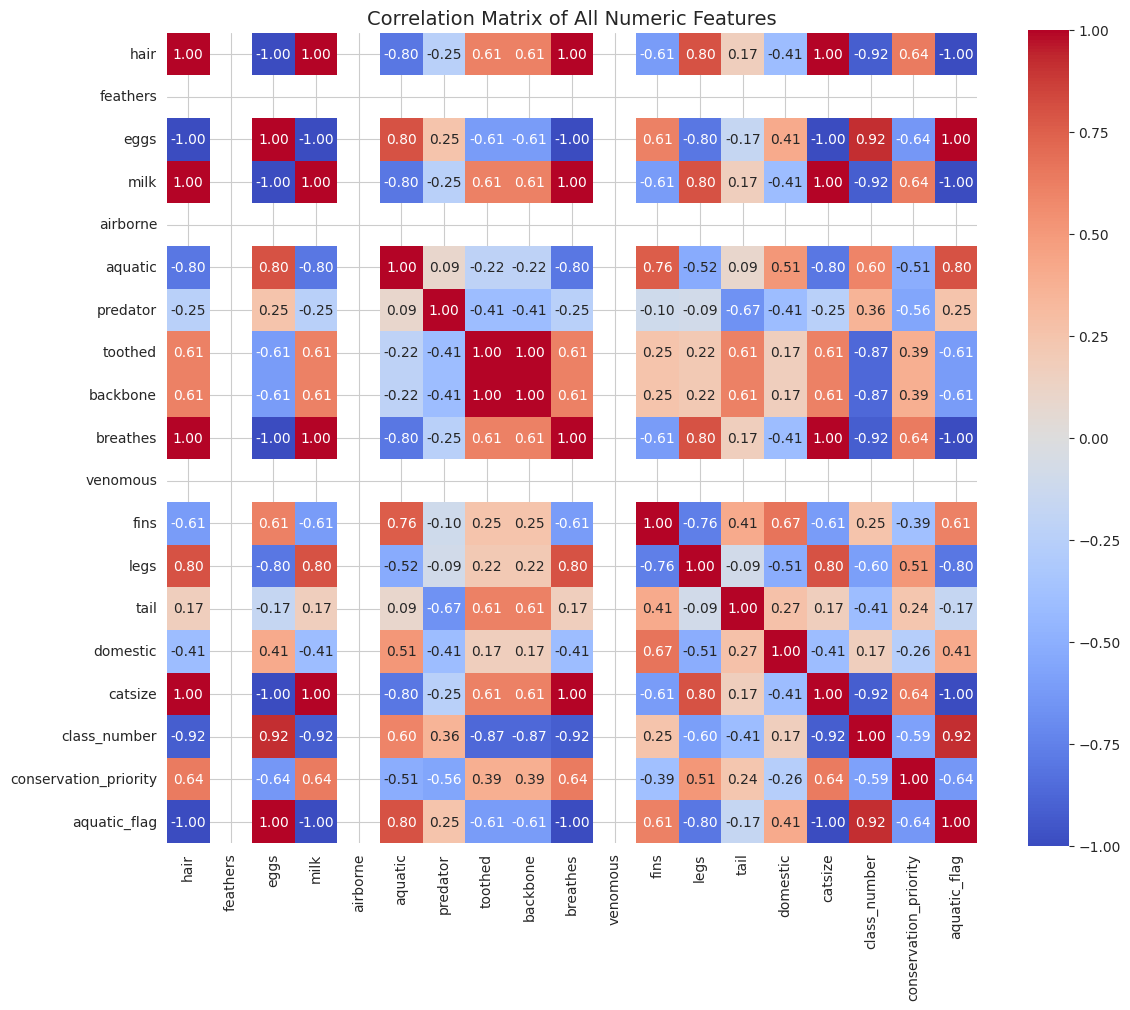


Task B Statistical Analysis Complete!


In [5]:
# --------------------------------------------------------------
#  TASK B – STATISTICAL ANALYSIS (Class Imbalance, Low Variance, High Correlation)
# --------------------------------------------------------------

import pandas as pd
import json
from pathlib import Path
from typing import List, Dict, Any
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --------------------------------------------------------------
# 1. CREATE FILES (same as before)
# --------------------------------------------------------------
def _create_files():
    zoo = """animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
buffalo,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
calf,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
carp,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,4
catfish,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
cavy,1,0,0,1,0,0,0,1,1,1,0,0,4,0,1,0,1
cheetah,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
chicken,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0,2
chub,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
clam,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,7
crab,0,0,1,0,0,1,1,0,0,0,0,0,4,0,0,0,7
crayfish,0,0,1,0,0,1,1,0,0,0,0,0,6,0,0,0,7
crow,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,0,2
deer,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
dogfish,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,1,4
dolphin,0,0,0,1,0,1,1,1,1,1,0,1,0,1,0,1,1
dove,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0,2
duck,0,1,1,0,1,1,0,0,1,1,0,0,2,1,0,0,2
elephant,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
flamingo,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,1,2
flea,0,0,1,0,0,0,0,0,0,1,0,0,6,0,0,0,6
frog,0,0,1,0,0,1,1,1,1,1,0,0,4,0,0,0,5
frog,0,0,1,0,0,1,1,1,1,1,1,0,4,0,0,0,5
fruitbat,1,0,0,1,1,0,0,1,1,1,0,0,2,1,0,0,1
giraffe,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
girl,1,0,0,1,0,0,1,1,1,1,0,0,2,0,1,1,1
gnat,0,0,1,0,1,0,0,0,0,1,0,0,6,0,0,0,6
goat,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
gorilla,1,0,0,1,0,0,0,1,1,1,0,0,2,0,0,1,1
gull,0,1,1,0,1,1,1,0,1,1,0,0,2,1,0,0,2
haddock,0,0,1,0,0,1,0,1,1,0,0,1,0,1,0,0,4
hamster,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,0,1
hare,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,0,1
hawk,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,0,2
herring,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
honeybee,1,0,1,0,1,0,0,0,0,1,1,0,6,0,1,0,6
housefly,1,0,1,0,1,0,0,0,0,1,0,0,6,0,0,0,6
kiwi,0,1,1,0,0,0,1,0,1,1,0,0,2,1,0,0,2
ladybird,0,0,1,0,1,0,1,0,0,1,0,0,6,0,0,0,6
lark,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2
leopard,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
lion,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
lobster,0,0,1,0,0,1,1,0,0,0,0,0,6,0,0,0,7
lynx,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
mink,1,0,0,1,0,1,1,1,1,1,0,0,4,1,0,1,1
mole,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,0,1
mongoose,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
moth,1,0,1,0,1,0,0,0,0,1,0,0,6,0,0,0,6
newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5
octopus,0,0,1,0,0,1,1,0,0,0,0,0,8,0,0,1,7
opossum,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,0,1
oryx,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
ostrich,0,1,1,0,0,0,0,0,1,1,0,0,2,1,0,1,2
parakeet,0,1,1,0,1,0,0,0,1,1,0,0,2,1,1,0,2
penguin,0,1,1,0,0,1,1,0,1,1,0,0,2,1,0,1,2
pheasant,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2
pike,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,1,4
piranha,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
pitviper,0,0,1,0,0,0,1,1,1,1,1,0,0,1,0,0,3
platypus,1,0,1,1,0,1,1,0,1,1,0,0,4,1,0,1,1
polecat,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
pony,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
porpoise,0,0,0,1,0,1,1,1,1,1,0,1,0,1,0,1,1
puma,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
pussycat,1,0,0,1,0,0,1,1,1,1,0,0,4,1,1,1,1
raccoon,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
reindeer,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1
rhea,0,1,1,0,0,0,1,0,1,1,0,0,2,1,0,1,2
scorpion,0,0,0,0,0,0,1,0,0,1,1,0,8,1,0,0,7
seahorse,0,0,1,0,0,1,0,1,1,0,0,1,0,1,0,0,4
seal,1,0,0,1,0,1,1,1,1,1,0,1,0,0,0,1,1
sealion,1,0,0,1,0,1,1,1,1,1,0,1,2,1,0,1,1
seasnake,0,0,0,0,0,1,1,1,1,0,1,0,0,1,0,0,3
seawasp,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,7
skimmer,0,1,1,0,1,1,1,0,1,1,0,0,2,1,0,0,2
skua,0,1,1,0,1,1,1,0,1,1,0,0,2,1,0,0,2
slowworm,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,3
slug,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7
sole,0,0,1,0,0,1,0,1,1,0,0,1,0,1,0,0,4
sparrow,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2
squirrel,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,0,1
starfish,0,0,1,0,0,1,1,0,0,0,0,0,5,0,0,0,7
stingray,0,0,1,0,0,1,1,1,1,0,1,1,0,1,0,1,4
swan,0,1,1,0,1,1,0,0,1,1,0,0,2,1,0,1,2
termite,0,0,1,0,0,0,0,0,0,1,0,0,6,0,0,0,6
toad,0,0,1,0,0,1,0,1,1,1,0,0,4,0,0,0,5
tortoise,0,0,1,0,0,0,0,0,1,1,0,0,4,1,0,1,3
tuatara,0,0,1,0,0,0,1,1,1,1,0,0,4,1,0,0,3
tuna,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,1,4
vampire,1,0,0,1,1,0,0,1,1,1,0,0,2,1,0,0,1
vole,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,0,1
vulture,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,1,2
wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7
wren,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2"""
    Path("/content/zoo.csv").write_text(zoo.strip() + "\n")

    cls = """Class_Number,Number_Of_Animal_Species_In_Class,Class_Type,Animal_Names
1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf, cavy, cheetah, deer, dolphin, elephant, fruitbat, giraffe, girl, goat, gorilla, hamster, hare, leopard, lion, lynx, mink, mole, mongoose, opossum, oryx, platypus, polecat, pony, porpoise, puma, pussycat, raccoon, reindeer, seal, sealion, squirrel, vampire, vole, wallaby, wolf"
2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, hawk, kiwi, lark, ostrich, parakeet, penguin, pheasant, rhea, skimmer, skua, sparrow, swan, vulture, wren"
3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, herring, pike, piranha, seahorse, sole, stingray, tuna"
5,4,Amphibian,"frog, frog, newt, toad"
6,8,Bug,"flea, gnat, honeybee, housefly, ladybird, moth, termite, wasp"
7,10,Invertebrate,"clam, crab, crayfish, lobster, octopus, scorpion, seawasp, slug, starfish, worm"
"""
    Path("/content/class.csv").write_text(cls.strip() + "\n")

    aux = """[
  {"animal_name":"aardvark","habitat":"savanna","diet":"insectivore","conservation_status":"least concern"},
  {"animal_name":"antelope","habitat":"grasslands","diet":"herbivore","conservation":"near threatened"},
  {"animal_name":"bass","habitat":"freshwater","diet":"carnivore","conservation_status":"least"},
  {"animal_name":"bear","habitats":"forest","diet":"omnivore","conservation_status":"vulnerable"},
  {"animal_name":"boar","habitat":"forest","diet":"omnivor","status":"least concern"},
  {"animal_name":"buffalo","habitat":"grasslands","diet_type":"herbivore","conservation":"endangered"},
  {"animal_name":"calf","habitat":"domestic","diet":"herbivore"},
  {"animal_name":"carp","habitat":"fresh water","diet":"omnivore","conservation_status":"least concern"},
  {"animal_name":"catfish","habitat":"FreshWater","diet":"carnivore"},
  {"animal_name":"clam","habitat":"marine","diet":"filter_feeder","conservation_status":"least concern"},
  {"animal_name":"crab","habitat":"marine/coastal","diet":"omnivore","conservation":"least concern"},
  {"animal_name":"deer","habitat":"Forest","diet":"Herbivore","conservation_status":"vulnerable"}
]"""
    Path("/content/auxiliary_metadata.json").write_text(aux.strip() + "\n")


# --------------------------------------------------------------
# 2. LOAD + PREPARE (Task E + F)
# --------------------------------------------------------------
def _load_aux_json(p: Path) -> List[Dict[str, Any]]:
    out = []
    with p.open(encoding="utf-8") as f:
        try: data = json.load(f)
        except: f.seek(0); data = [json.loads(l) for l in f if l.strip()]
        if not isinstance(data, list): return out
        for rec in data:
            try:
                processed_rec = {}
                for k, v in rec.items():
                    k_norm = k.strip().lower().replace(" ", "_")
                    if k_norm == "habitats":
                        k_norm = "habitat"
                    if k_norm == "status": # assuming 'status' refers to conservation_status
                        k_norm = "conservation_status"
                    if k_norm == "diet_type":
                        k_norm = "diet"
                    processed_rec[k_norm] = v

                if "animal_name" not in processed_rec: continue

                # Set defaults for all expected columns
                processed_rec.setdefault("habitat", None)
                processed_rec.setdefault("diet", None)
                processed_rec.setdefault("conservation_status", None)
                processed_rec.setdefault("conservation", None)

                # Special handling for conservation: if conservation_status is None but conservation has a value, use it.
                if processed_rec["conservation_status"] is None and processed_rec["conservation"] is not None:
                    processed_rec["conservation_status"] = processed_rec["conservation"]
                # Also, if conservation is None but conservation_status has a value, use it for conservation.
                if processed_rec["conservation"] is None and processed_rec["conservation_status"] is not None:
                    processed_rec["conservation"] = processed_rec["conservation_status"]

                # Ensure only the desired columns and their normalized values are kept
                final_rec = {
                    "animal_name": processed_rec["animal_name"],
                    "habitat": processed_rec["habitat"],
                    "diet": processed_rec["diet"],
                    "conservation_status": processed_rec["conservation_status"],
                    "conservation": processed_rec["conservation"],
                }
                out.append(final_rec)
            except Exception as e:
                # print(f"Error processing record {rec}: {e}") # For debugging
                continue
    return out

def load_and_prepare():
    zoo_df = pd.read_csv("/content/zoo.csv")
    zoo_df.columns = [c.strip().lower() for c in zoo_df.columns]

    cls_df = pd.read_csv("/content/class.csv")
    cls_df.columns = [c.strip().lower() for c in cls_df.columns]
    cls_expl = (cls_df
                .assign(animal_name=cls_df["animal_names"].str.split(", "))
                .explode("animal_name")
                .drop(columns=["animal_names","number_of_animal_species_in_class"], errors="ignore"))
    cls_expl["animal_name"] = cls_expl["animal_name"].astype(str).str.strip().str.lower()
    cls_clean = cls_expl[["animal_name","class_number","class_type"]]

    aux_records = _load_aux_json(Path("/content/auxiliary_metadata.json"))
    aux_df = pd.DataFrame(aux_records)
    if not aux_df.empty:
        aux_df["animal_name"] = aux_df["animal_name"].astype(str).str.strip().str.lower()

    df = zoo_df.copy()
    df["animal_name"] = df["animal_name"].str.strip().str.lower()
    df = df.merge(cls_clean, on="animal_name", how="left")

    # Resolve class_type column duplication after merge
    if 'class_type_y' in df.columns:
        df['class_type'] = df['class_type_y']
        df = df.drop(columns=['class_type_x', 'class_type_y'], errors='ignore')
    elif 'class_type_x' in df.columns:
        df['class_type'] = df['class_type_x']
        df = df.drop(columns=['class_type_x'], errors='ignore')

    if not aux_df.empty:
        df = df.merge(aux_df, on="animal_name", how="left")

    # Task E: Drop missing aux
    aux_cols = ["habitat","diet","conservation_status","conservation"]
    aux_present = [c for c in aux_cols if c in df.columns]
    df = df.dropna(subset=aux_present, how="any")

    # Task F: Features
    priority_map = {"endangered":5,"vulnerable":4,"near threatened":3,"least":1,"least concern":1}
    def get_priority(v):
        if pd.isna(v): return 0
        v = str(v).lower()
        for k, s in priority_map.items():
            if k in v: return s
        return 0
    df["conservation_priority"] = df["conservation_status"].fillna(df["conservation"]).apply(get_priority)
    df["aquatic_flag"] = df["habitat"].astype(str).str.lower().apply(lambda x: 1 if "water" in x or "marine" in x else 0)

    df["animal_name"] = df["animal_name"].str.title()
    return df


# --------------------------------------------------------------
# 3. RUN STATISTICAL ANALYSIS
# --------------------------------------------------------------
print("Creating files...")
_create_files()

print("\nLoading & preparing data...")
df = load_and_prepare()
print(f"Final dataset: {df.shape}")

# Select only numeric columns for stats
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_df = df[num_cols]

# --------------------------------------------------------------
# 1. CLASS IMBALANCE RATIO
# --------------------------------------------------------------
class_counts = df["class_type"].value_counts()
largest = class_counts.max()
smallest = class_counts.min()
imbalance_ratio = largest / smallest

print(f"\nClass Distribution:")
print(class_counts)
print(f"\nClass Imbalance Ratio = {largest} / {smallest} = {imbalance_ratio:.2f}")

# --------------------------------------------------------------
# 2. LOW VARIANCE FEATURES (variance < 0.01)
# --------------------------------------------------------------
variances = num_df.var()
low_var_features = variances[variances < 0.01].index.tolist()

print(f"\nLow Variance Features (variance < 0.01):")
if low_var_features:
    for f in low_var_features:
        print(f"  - {f}: {variances[f]:.6f}")
else:
    print("  None")

# --------------------------------------------------------------
# 3. HIGHLY CORRELATED PAIRS (|corr| > 0.8)
# --------------------------------------------------------------
corr_matrix = num_df.corr()
high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["Feature1", "Feature2", "Correlation"]
high_corr = high_corr[abs(high_corr["Correlation"]) > 0.8]

print(f"\nHighly Correlated Pairs (|corr| > 0.8):")
if not high_corr.empty:
    for _, row in high_corr.iterrows():
        print(f"  - {row['Feature1']} ↔ {row['Feature2']}: {row['Correlation']:.3f}")
else:
    print("  None")

# --------------------------------------------------------------
# BONUS: Heatmap of correlations
# --------------------------------------------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Correlation Matrix of All Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTask B Statistical Analysis Complete!")